# KARUR VYSYA BANK (KVB)
## STOCK PRICE PREDICTION

### Using Daily High Price

**Company:** Karur Vysya Bank (KVB)  
**Period:** 01-07-2026 to 28-08-2026  
**Target Variable:** Daily High Price  
**Machine Learning Technique:** Regression  
**Algorithm:** Linear RegressioN

In [1]:
import yfinance as yf
import pandas as pd

symbol = "KARURVYSYA.NS"

data = yf.download(
    symbol,
    start="2026-07-01",
    end="2026-08-29",
    auto_adjust=False
)

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,KARURVYSYA.NS,KARURVYSYA.NS,KARURVYSYA.NS,KARURVYSYA.NS,KARURVYSYA.NS,KARURVYSYA.NS
Date,,,,,,
2026-07-01,297.783997,300.100006,301.649994,294.299988,296.649994,5384348
2026-07-02,291.681488,293.950012,302.000000,293.200012,300.000000,3063062
2026-07-03,289.548035,291.799988,297.000000,288.799988,295.299988,1904516
2026-07-06,301.802734,304.149994,307.149994,291.149994,293.600006,4377186
2026-07-07,302.001221,304.350006,306.799988,300.500000,306.000000,2240398


In [2]:
kvb_high = data[['High']].copy()

kvb_high.head()

Price,High
Ticker,KARURVYSYA.NS
Date,
2026-07-01,301.649994
2026-07-02,302.000000
2026-07-03,297.000000
2026-07-06,307.149994
2026-07-07,306.799988


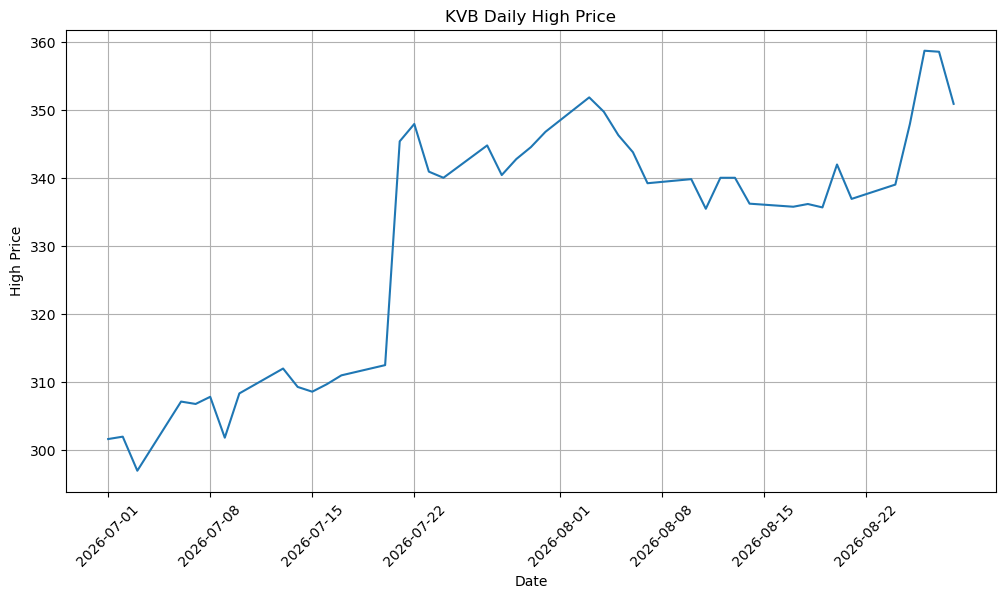

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))

plt.plot(kvb_high.index, kvb_high['High'])

plt.xlabel('Date')
plt.ylabel('High Price')
plt.title('KVB Daily High Price')

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [6]:
# High Price values
prices = kvb_high['High'].values

# Display number of data points
print("Number of data points:", len(prices))

Number of data points: 43


In [7]:
X = prices[:-1]
y = prices[1:]

print("X values:", len(X))
print("y values:", len(y))

X values: 42
y values: 42


In [9]:
from sklearn.model_selection import train_test_split
X = X.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("X_train:", len(X_train))
print("X_test:", len(X_test))
print("y_train:", len(y_train))
print("y_test:", len(y_test))

C:\Users\GOD\Anaconda3\envs\ai310\lib\site-packages\scipy\__init__.py:169: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


X_train: 33
X_test: 9
y_train: 33
y_test: 9


In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [11]:
y_pred = model.predict(X_test)

print("Prediction completed")
print("Number of predictions:", len(y_pred))

Prediction completed
Number of predictions: 9


In [11]:
for actual, predicted in zip(y_test, y_pred):
    actual = float(actual)
    predicted = float(predicted)

    print("Actual:", round(actual, 2),
          "Predicted:", round(predicted, 2))

Actual: 343.75 Predicted: 345.51
Actual: 345.35 Predicted: 313.87
Actual: 309.3 Predicted: 313.4
Actual: 339.2 Predicted: 343.17
Actual: 307.85 Predicted: 308.52
Actual: 358.65 Predicted: 347.06
Actual: 342.75 Predicted: 340.02
Actual: 340.0 Predicted: 335.38
Actual: 340.0 Predicted: 339.65


C:\Users\GOD\AppData\Local\Temp\ipykernel_1128\2929121561.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual = float(actual)
C:\Users\GOD\AppData\Local\Temp\ipykernel_1128\2929121561.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted = float(predicted)


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 2))

MAE : 6.81
MSE : 132.27
RMSE: 11.5
R2 Score: 0.47


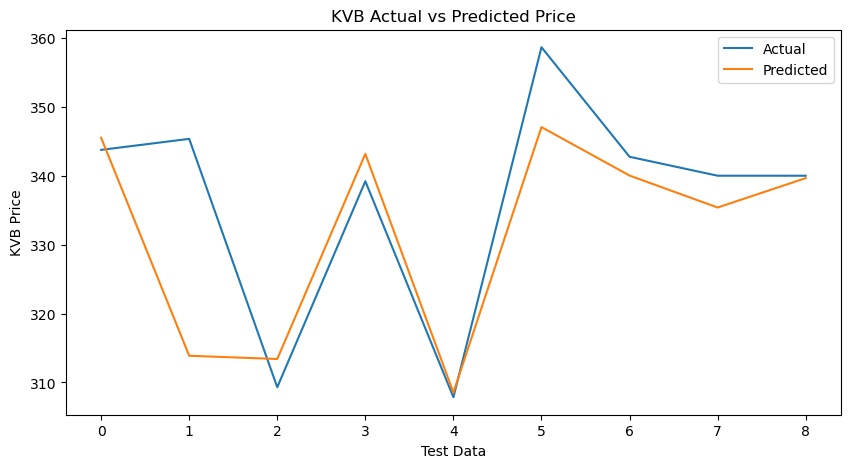

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.xlabel("Test Data")
plt.ylabel("KVB Price")
plt.title("KVB Actual vs Predicted Price")

plt.legend()
plt.show()

In [14]:
comparison = pd.DataFrame({
    "Actual": y_test.flatten(),
    "Predicted": y_pred.flatten()
})

print(comparison)

       Actual   Predicted
0  343.750000  345.509168
1  345.350006  313.868167
2  309.299988  313.399411
3  339.200012  343.165390
4  307.850006  308.524342
5  358.649994  347.056056
6  342.750000  340.024722
7  340.000000  335.384059
8  340.000000  339.649724


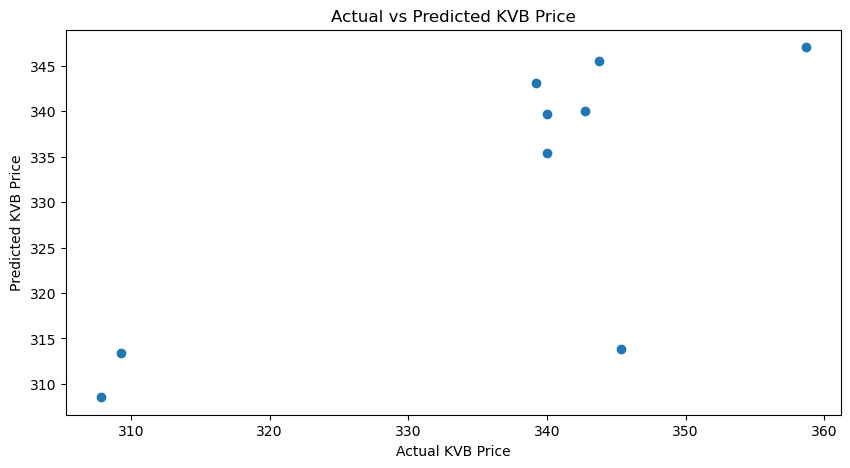

In [15]:
plt.figure(figsize=(10, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual KVB Price")
plt.ylabel("Predicted KVB Price")
plt.title("Actual vs Predicted KVB Price")

plt.show()

In [16]:
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

Coefficient: [[0.93751115]]
Intercept: [20.89593132]


In [17]:
kvb_high = data[['High']].copy()

kvb_high.tail()

Price,High
Ticker,KARURVYSYA.NS
Date,
2026-08-24,339.000000
2026-08-25,347.899994
2026-08-26,358.649994
2026-08-27,358.500000
2026-08-28,350.850006


In [18]:
print(kvb_high.head())
print(kvb_high.columns)

Price               High
Ticker     KARURVYSYA.NS
Date                    
2026-07-01    301.649994
2026-07-02    302.000000
2026-07-03    297.000000
2026-07-06    307.149994
2026-07-07    306.799988
MultiIndex([('High', 'KARURVYSYA.NS')],
           names=['Price', 'Ticker'])


In [19]:
high_price = kvb_high[('High', 'KARURVYSYA.NS')]

print(high_price.head())

Date
2026-07-01    301.649994
2026-07-02    302.000000
2026-07-03    297.000000
2026-07-06    307.149994
2026-07-07    306.799988
Name: (High, KARURVYSYA.NS), dtype: float64


In [20]:
X = high_price.shift(1).dropna().to_frame(name='Previous_High')
y = high_price.loc[X.index]

print("X:")
print(X.head())

print("\ny:")
print(y.head())

X:
            Previous_High
Date                     
2026-07-02     301.649994
2026-07-03     302.000000
2026-07-06     297.000000
2026-07-07     307.149994
2026-07-08     306.799988

y:
Date
2026-07-02    302.000000
2026-07-03    297.000000
2026-07-06    307.149994
2026-07-07    306.799988
2026-07-08    307.850006
Name: (High, KARURVYSYA.NS), dtype: float64


In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training and testing data split completed")

Training and testing data split completed


In [23]:
print("X columns:")
print(X.columns)

print("\nLast row of X:")
print(X.tail(1))

X columns:
Index(['Previous_High'], dtype='object')

Last row of X:
            Previous_High
Date                     
2026-08-28          358.5


In [24]:
high_price = kvb_high[('High', 'KARURVYSYA.NS')]

print(high_price.head())

Date
2026-07-01    301.649994
2026-07-02    302.000000
2026-07-03    297.000000
2026-07-06    307.149994
2026-07-07    306.799988
Name: (High, KARURVYSYA.NS), dtype: float64


In [25]:
X = high_price.shift(1).dropna().to_frame(name='Previous_High')
y = high_price.loc[X.index]

print("X:")
print(X.head())

print("\ny:")
print(y.head())

X:
            Previous_High
Date                     
2026-07-02     301.649994
2026-07-03     302.000000
2026-07-06     297.000000
2026-07-07     307.149994
2026-07-08     306.799988

y:
Date
2026-07-02    302.000000
2026-07-03    297.000000
2026-07-06    307.149994
2026-07-07    306.799988
2026-07-08    307.850006
Name: (High, KARURVYSYA.NS), dtype: float64


In [26]:
last_high = high_price.iloc[-1]

next_day_prediction = model.predict([[last_high]])

print("Last High Price:", last_high)
print("Predicted KVB High Price for 31-08-2026:",
      next_day_prediction[0])

Last High Price: 350.8500061035156
Predicted KVB High Price for 31-08-2026: [349.82172533]


In [ ]:
Actual data period: 01-07-2026 to 28-08-2026
Target: Daily High Price
Algorithm: Linear Regression
MAE: 6.81
RMSE: 11.50
R² Score: 0.47
Predicted High for 31-08-2026: ₹349.82
